In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_thr = pd.read_excel('../datasets/03_labeling.xlsx')
df_thr.info()
df_thr.head()

<class 'pandas.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   platform          1758 non-null   str  
 1   text              1758 non-null   str  
 2   cleaning          1758 non-null   str  
 3   case_folding      1758 non-null   str  
 4   normalisasi_kata  1758 non-null   str  
 5   tokenize          1758 non-null   str  
 6   stopword removal  1758 non-null   str  
 7   stemming          1758 non-null   str  
 8   score             1758 non-null   int64
 9   sentiment         1758 non-null   str  
dtypes: int64(1), str(9)
memory usage: 137.5 KB


,platform,text,cleaning,case_folding,normalisasi_kata,tokenize,stopword removal,stemming,score,sentiment
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,asa te boga walikotahanya KDM yg ku punya,asa te boga walikotahanya kdm yg ku punya,"asa henteu boga wali kota, hanya kdm yang ku p...","['asa', 'henteu', 'boga', 'wali', 'kota,', 'ha...","asa henteu boga wali kota, kdm ku",asa henteu boga wali kota kdm ku,-1,Negatif
1,tiktok,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,"['sedih', 'gara', 'gara', 'bapak', 'ini']",sedih gara gara,sedih gara gara,-3,Negatif
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",hade goreng ku basa ieu mah Pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,"['hade', 'goreng', 'ku', 'basa', 'ieu', 'mah',...",hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,-2,Negatif
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Ciamis ts cair Minggu kmari Tasik mah kmha cer...,ciamis ts cair minggu kmari tasik mah kmha cer...,ciamis atos cair minggu kamari tasikmalaya mah...,"['ciamis', 'atos', 'cair', 'minggu', 'kamari',...",ciamis atos cair minggu kamari tasikmalaya mah...,ciamis atos cair minggu kamar tasikmalaya mah ...,0,Negatif
4,tiktok,nyesel milih dia,nyesel milih dia,nyesel milih dia,menyesal memilih dia,"['menyesal', 'memilih', 'dia']",menyesal memilih,sesal pilih,-1,Negatif


# **5. ASPECT BASED SENTIMENT ANALYSIS**

In [3]:
keyword_rules = {

    'THR': [
        'tunjangan hari raya', 'juga belum cair', 'hari raya ya',
        'hari raya pegawai', 'raya pegawai negeri', 'hari raya aparatur',
        'raya aparatur sipil', 'cair tunjangan hari', 'bandung juga belum',
        'thr'
    ],

    'ASN': [
        'aparatur sipil negara', 'pegawai negeri sipil', 'dengan perjanjian kerja',
        'pemerintah dengan perjanjian', 'raya apartur sipil', 'asn', 'pns',
        'aparatur', 'sipil', 'negara', 'pegawai', 'negeri', 'perjanjian',
        'kerja', 'pppk', 'p3k', 'paruh', 'pwaruh waktu'
    ],

    'Kinerja Pemkot': [
        'pegawai pemerintah dengan', ' pemerintah dengan perjanjian kerja',
        'wali', 'kota', 'walai kota', 'walikota', 'pemerintah', 'pemkot',
        'viman', 'pemimpin', 'bogo', 'belegug', 'lari', 'lumpat', 'joging',
        'jogging', 'mundur', 'kemunduran', 'barodo', 'suara', 'pemilihan',
        'pemilu', 'sedih', 'mimpin', 'begug', 'kinerja', 'pemkot'
    ],

    'Infrastruktur': [
        'jalan', 'rusak', 'pejet', 'jalan rusak', 'jalan pejet', 'jalan poek',
        'jalan paroek', 'cikurubuk', 'infra', 'struktur', 'infrastruktur',
        'logak', 'padayungan', 'lampu', 'merah', 'banung', 'pembangunan'
    ]
}

In [4]:
import re

def assign_keyword(text, keyword_rules):
    if pd.isna(text):
        return None

    text = str(text).lower()

    for keyword, terms in keyword_rules.items():
        for term in terms:
            # gunakan word boundary agar pencarian lebih aman
            pattern = rf'\b{re.escape(term.lower())}\b'

            if re.search(pattern, text):
                return keyword

    return 'Lainnya'

In [5]:
df_thr['keyword'] = df_thr['normalisasi_kata'].apply(
    lambda x: assign_keyword(x, keyword_rules)
)

In [6]:
df_thr.iloc[61:120][
    ['normalisasi_kata', 'sentiment', 'keyword']
]

,normalisasi_kata,sentiment,keyword
61,gawe nyata heula kakara menta thr ulah ukur mi...,Negatif,THR
62,saha sih ieu teh ayah saya tasikmalaya teu kenal,Negatif,Lainnya
63,wios di anjuk ge ngarah teu langsung habis kan...,Positif,Kinerja Pemkot
64,benar ceuk hadist bakal loba jalma barodo jadi...,Negatif,Kinerja Pemkot
65,matak ari memberikan suara ulah eleh ku duit 100,Negatif,Kinerja Pemkot
66,wali kota gagal kalau saya mah malu jadi wali ...,Negatif,Kinerja Pemkot
67,tunjangan hari raya kango meser sapatu sareng ...,Negatif,THR
68,kejadian tersebut sudah di paparkan oleh kdm,Negatif,Lainnya
69,secara moral pasti rugi eung di pegawai kantor...,Positif,ASN
70,planga plongo kitu,Negatif,Lainnya


In [7]:
with pd.option_context('display.max_colwidth', None):
    display(df_thr.loc[[74], ['normalisasi_kata', 'sentiment', 'keyword']])

,normalisasi_kata,sentiment,keyword
74,ari sugan keur nyileungleuman korsi keneh eh ternyata aya karak hudang cik atuh sing aya kak gadag lain hees wae sok sidak kak tiap instansi sidak kak tiap daerah ulah asal jadi wali kota,Negatif,Kinerja Pemkot


In [8]:
df_thr[df_thr['keyword'] == 'THR']

,platform,text,cleaning,case_folding,normalisasi_kata,tokenize,stopword removal,stemming,score,sentiment,keyword
17,tiktok,"seumur umur PNS THR bisa begini, hadeeuuhhh",seumur umur PNS THR bisa begini hadeeuuhhh,seumur umur pns thr bisa begini hadeeuuhhh,seumur umur pegawai negeri sipil tunjangan har...,"['seumur', 'umur', 'pegawai', 'negeri', 'sipil...",seumur umur pegawai negeri sipil tunjangan ray...,umur umur pegawai negeri sipil tunjang raya ha...,-1,Negatif,THR
19,tiktok,THR mana,THR mana,thr mana,tunjangan hari raya mana,"['tunjangan', 'hari', 'raya', 'mana']",tunjangan raya,tunjang raya,-1,Negatif,THR
30,facebook,pemecah rekor baru kali ini ada THR..DI Anjuk,pemecah rekor baru kali ini ada THRDI Anjuk,pemecah rekor baru kali ini ada thrdi anjuk,pemecah rekor baru kali ini ada thr di anjuk,"['pemecah', 'rekor', 'baru', 'kali', 'ini', 'a...",pemecah rekor kali thr anjuk,pecah rekor kali thr anjuk,0,Negatif,THR
45,facebook,sugan teh tasik eweh walikota an. pedah jalan ...,sugan teh tasik eweh walikota an pedah jalan l...,sugan teh tasik eweh walikota an pedah jalan l...,sugan teh tasikmalaya eweh wali kota an pedah ...,"['sugan', 'teh', 'tasikmalaya', 'eweh', 'wali'...",sugan teh tasikmalaya eweh wali kota an pedah ...,sugan teh tasikmalaya eweh wali kota an dah ja...,-8,Negatif,THR
55,facebook,THR (Tasik HeRang),THR Tasik HeRang,thr tasik herang,tunjangan hari raya tasikmalaya herang,"['tunjangan', 'hari', 'raya', 'tasikmalaya', '...",tunjangan raya tasikmalaya herang,tunjang raya tasikmalaya hang,-1,Negatif,THR
...,...,...,...,...,...,...,...,...,...,...,...
1748,instagram,Assalamualaikum bapak viman dan jajarannya yg ...,Assalamualaikum bapak viman dan jajarannya yg ...,assalamualaikum bapak viman dan jajarannya yg ...,assalamualaikum bapak viman dan jajarannya yan...,"['assalamualaikum', 'bapak', 'viman', 'dan', '...",assalamualaikum viman jajarannya terhormat moh...,assalamualaikum viman jajar hormat mohon gerak...,-2,Negatif,THR
1749,instagram,"Thr ulah di cicil pa, jiga ka bank emok wae",Thr ulah di cicil pa jiga ka bank emok wae,thr ulah di cicil pa jiga ka bank emok wae,tunjangan hari raya ulah di cicil apa jiga kak...,"['tunjangan', 'hari', 'raya', 'ulah', 'di', 'c...",tunjangan raya ulah cicil jiga kak bank emok wae,tunjang raya ulah cicil jiga kak bank emok wae,-3,Negatif,THR
1751,instagram,"perjuangkn ath pa THR PNS,, piraku cair april.",perjuangkn ath pa THR PNS piraku cair april,perjuangkn ath pa thr pns piraku cair april,perjuangkn ath apa tunjangan hari raya pegawai...,"['perjuangkn', 'ath', 'apa', 'tunjangan', 'har...",perjuangkn ath tunjangan raya pegawai negeri s...,perjuangkn ath tunjang raya pegawai negeri sip...,-2,Negatif,THR
1754,instagram,THR,THR,thr,tunjangan hari raya,"['tunjangan', 'hari', 'raya']",tunjangan raya,tunjang raya,-1,Negatif,THR


In [9]:
df_thr.loc[
    df_thr['keyword'] == 'THR',
    ['normalisasi_kata', 'sentiment']
]

,normalisasi_kata,sentiment
17,seumur umur pegawai negeri sipil tunjangan har...,Negatif
19,tunjangan hari raya mana,Negatif
30,pemecah rekor baru kali ini ada thr di anjuk,Negatif
45,sugan teh tasikmalaya eweh wali kota an pedah ...,Negatif
55,tunjangan hari raya tasikmalaya herang,Negatif
...,...,...
1748,assalamualaikum bapak viman dan jajarannya yan...,Negatif
1749,tunjangan hari raya ulah di cicil apa jiga kak...,Negatif
1751,perjuangkn ath apa tunjangan hari raya pegawai...,Negatif
1754,tunjangan hari raya,Negatif


In [10]:
distribusi_keyword = pd.crosstab(
    df_thr['keyword'],
    df_thr['sentiment']
)

distribusi_keyword['total'] = distribusi_keyword.sum(axis=1)
distribusi_keyword

sentiment,Negatif,Positif,total
keyword,,,
ASN,57,25,82
Infrastruktur,26,3,29
Kinerja Pemkot,221,21,242
Lainnya,877,200,1077
THR,308,20,328


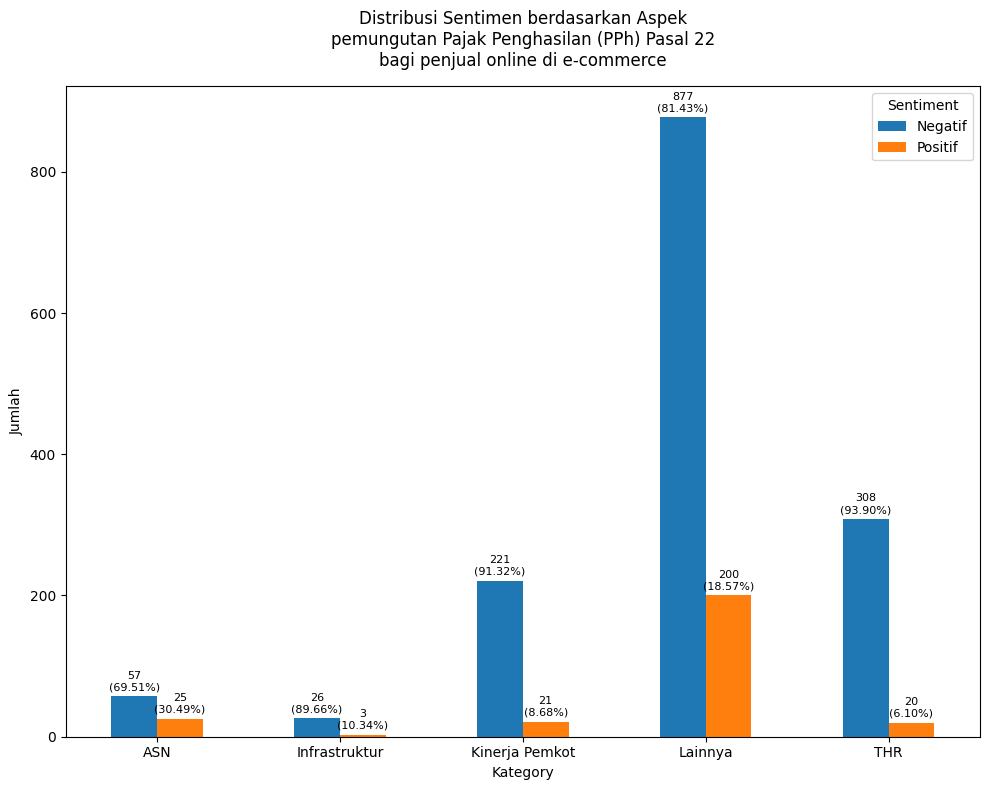

In [11]:
pivot = df_thr.groupby(['keyword', 'sentiment']).size().unstack(fill_value=0)

ax = pivot.plot(kind='bar', figsize=(10,8))
total_per_aspek = pivot.sum(axis=1)

for container in ax.containers:
    labels = []

    for bar in container:
        height = bar.get_height()

        if height > 0:
            x = bar.get_x() + bar.get_width()/2
            aspek_idx = int(round(x))
            aspek = pivot.index[aspek_idx]
            total = total_per_aspek[aspek]

            percentage = 100 * height / total
            labels.append(f'{int(height)}\n({percentage:.2f}%)')
        else:
            labels.append('')

    ax.bar_label(
        container,
        labels=labels,
        label_type='edge',
        padding=3,
        fontsize=8
    )

plt.title('Distribusi Sentimen berdasarkan Aspek\npemungutan Pajak Penghasilan (PPh) Pasal 22\nbagi penjual online di e-commerce', pad=15)
plt.xlabel('Kategory')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('../img/05 Distribusi Sentimen berdasarkan Aspek')

plt.show()

In [12]:
with pd.option_context('display.max_colwidth', None):
    display(df_thr.loc[
        0:59,
        ['normalisasi_kata', 'sentiment', 'keyword']
    ].query("keyword == 'Lainnya'"))    

,normalisasi_kata,sentiment,keyword
3,ciamis atos cair minggu kamari tasikmalaya mah kumaha ceritanya,Negatif,Lainnya
4,menyesal memilih dia,Negatif,Lainnya
6,ke1,Negatif,Lainnya
8,2,Negatif,Lainnya
9,parahhh,Negatif,Lainnya
13,mantap admin upp terus,Positif,Lainnya
14,aduh,Negatif,Lainnya
15,hadehhhhh,Negatif,Lainnya
16,deudeuh tidak tahu,Negatif,Lainnya
21,100rb aya keneh teu,Positif,Lainnya


In [13]:
df_thr.head()

,platform,text,cleaning,case_folding,normalisasi_kata,tokenize,stopword removal,stemming,score,sentiment,keyword
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,asa te boga walikotahanya KDM yg ku punya,asa te boga walikotahanya kdm yg ku punya,"asa henteu boga wali kota, hanya kdm yang ku p...","['asa', 'henteu', 'boga', 'wali', 'kota,', 'ha...","asa henteu boga wali kota, kdm ku",asa henteu boga wali kota kdm ku,-1,Negatif,Kinerja Pemkot
1,tiktok,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,"['sedih', 'gara', 'gara', 'bapak', 'ini']",sedih gara gara,sedih gara gara,-3,Negatif,Kinerja Pemkot
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",hade goreng ku basa ieu mah Pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,"['hade', 'goreng', 'ku', 'basa', 'ieu', 'mah',...",hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,-2,Negatif,Kinerja Pemkot
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Ciamis ts cair Minggu kmari Tasik mah kmha cer...,ciamis ts cair minggu kmari tasik mah kmha cer...,ciamis atos cair minggu kamari tasikmalaya mah...,"['ciamis', 'atos', 'cair', 'minggu', 'kamari',...",ciamis atos cair minggu kamari tasikmalaya mah...,ciamis atos cair minggu kamar tasikmalaya mah ...,0,Negatif,Lainnya
4,tiktok,nyesel milih dia,nyesel milih dia,nyesel milih dia,menyesal memilih dia,"['menyesal', 'memilih', 'dia']",menyesal memilih,sesal pilih,-1,Negatif,Lainnya


In [14]:
df_thr.to_excel('../datasets/05_absa.xlsx', index=False)
print('dataset berhasil di save')

dataset berhasil di save
